In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


<p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: center;
          font-size:260%;">
Pima Indians Diabetes EDA 
     </p>


<p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: left;
          font-size:150%;">
 1. BUSINESS OBJECTIVE & PROBLEM STATEMENT
     </p>
     
<p> This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage. </p>



 <p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: left;
          font-size:150%;">
 2. IMPORTING REQUIRED LIBRARIES
     </p>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv') 
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: left;
          font-size:150%;">
 3. DATA REVIEW & UNDERSTANDING DATA
     </p>

In [4]:
data.shape

(768, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
#check the columns of data
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Observations

1 Dataset has 768 rows and 9 columns

2 two columns BMI and DiabetesPedigreeFunction are float type, others are integer type.

3 There is no categorical variable.

<p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: left;
          font-size:150%;">
 4. DATA CLEANING 
     </p>
     
<p>
1. Checking missing/null values <br>
2. drop the column, if there are not useful <br>
3. data preparation: converting column to categorical variable <br>
4. Univariate analysis <br>
5. EDA <br>
6. corelation analysis </p>


<p style="padding: 10px;
          color:#0000FF;
          font-weight: bold;
          text-align: left;
          font-size:150%;">
Checking missing/null values
     </p>

In [8]:
#check the Null value 
round(data.isnull().sum()/len(data)*100,2)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

There is no null values in dataset.

Creating new variables

1 BMI Variable:
BMI is a person’s weight in kilograms divided by the square of height in meters. A high BMI can indicate high body fatness.

 If BMI is less than 18.5, it falls in the underweight range.
 
 If BMI is 18.5 to <25, it falls in the healthy weight range.
 
 If BMI is 25.0 to <30, it falls in the overweight range.
 
 If BMI is 30.0 or higher, it falls in the obesity range.


In [9]:
bmi_labels = ['Underweight','Healthy Weight','Overweight','Obesity']

data['BMI_Cat'] = pd.cut(data['BMI'],[0,18.5,25,30,data['BMI'].max()],labels=bmi_labels)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Cat
0,6,148,72,35,0,33.6,0.627,50,1,Obesity
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Healthy Weight
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obesity


Glucose

    A blood sugar level less than 140 mg/dL (7.8 mmol/L) is considered normal.
    A blood sugar level from 140 to 199 mg/dL (7.8 to 11.0 mmol/L) is considered prediabetes. This is sometimes referred to as impaired glucose tolerance.
    A blood sugar level of 200 mg/dL (11.1 mmol/L) or higher indicates type 2 diabetes.



In [10]:
data["Glucose_Cat"] = data["Glucose"].apply(lambda x: "Normal" if x < 140 else ("Prediabetes" if 140 <= x <= 199 else "Risk"))

Insulin

Insulin is a hormone (a chemical substance that acts as a messenger in the human body) that is secreted by an abdominal organ called the pancreas. It controls the breakdown of carbohydrates, fats and proteins in the body. It also guides the liver and muscles to store glucose and fat that can be used during periods of increased energy requirements and fasting. Insulin is a “key” that unlocks the cell gates so that glucose from the blood enters the cells. The cells of the muscle and fat tissue are dependent solely on insulin for glucose uptake and use.


In [11]:
data['Insulin'] = data['Insulin'].fillna(data.groupby(['BMI_Cat','Outcome','Glucose_Cat'])['Insulin'].transform('median'))

data["Insulin_Cat"] = data["Insulin"].apply(lambda x: "Normal" if (16 <= x <= 166) else "Abnormal")

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   BMI_Cat                   757 non-null    category
 10  Glucose_Cat               768 non-null    object  
 11  Insulin_Cat               768 non-null    object  
dtypes: category(1), float64(2), int64(7), object(2)
memory usage: 67.1+ KB


Now dataset has 3 more categorical variables.

### Check linear relation of numeric variable: EDA of numeric variables: plot pairplot of numeric variable 

In [13]:
cat_var=['BMI_Cat','Glucose_Cat','Insulin_Cat']
num_var=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

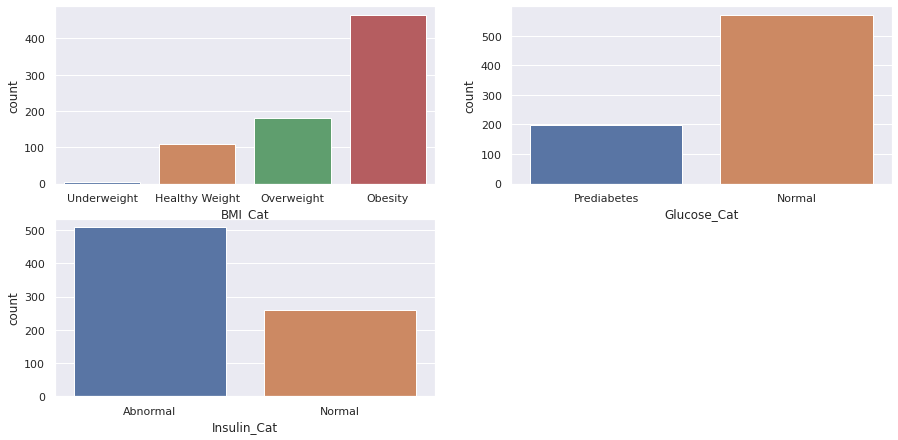

In [14]:
# Boxplot of categorical variables

plt.figure(figsize=(15, 15))
sns.set(style="darkgrid")
i=1
for col in cat_var:
    plt.subplot(4,2,i)
    sns.countplot(data=data, x=col, )
    i=i+1
plt.show()

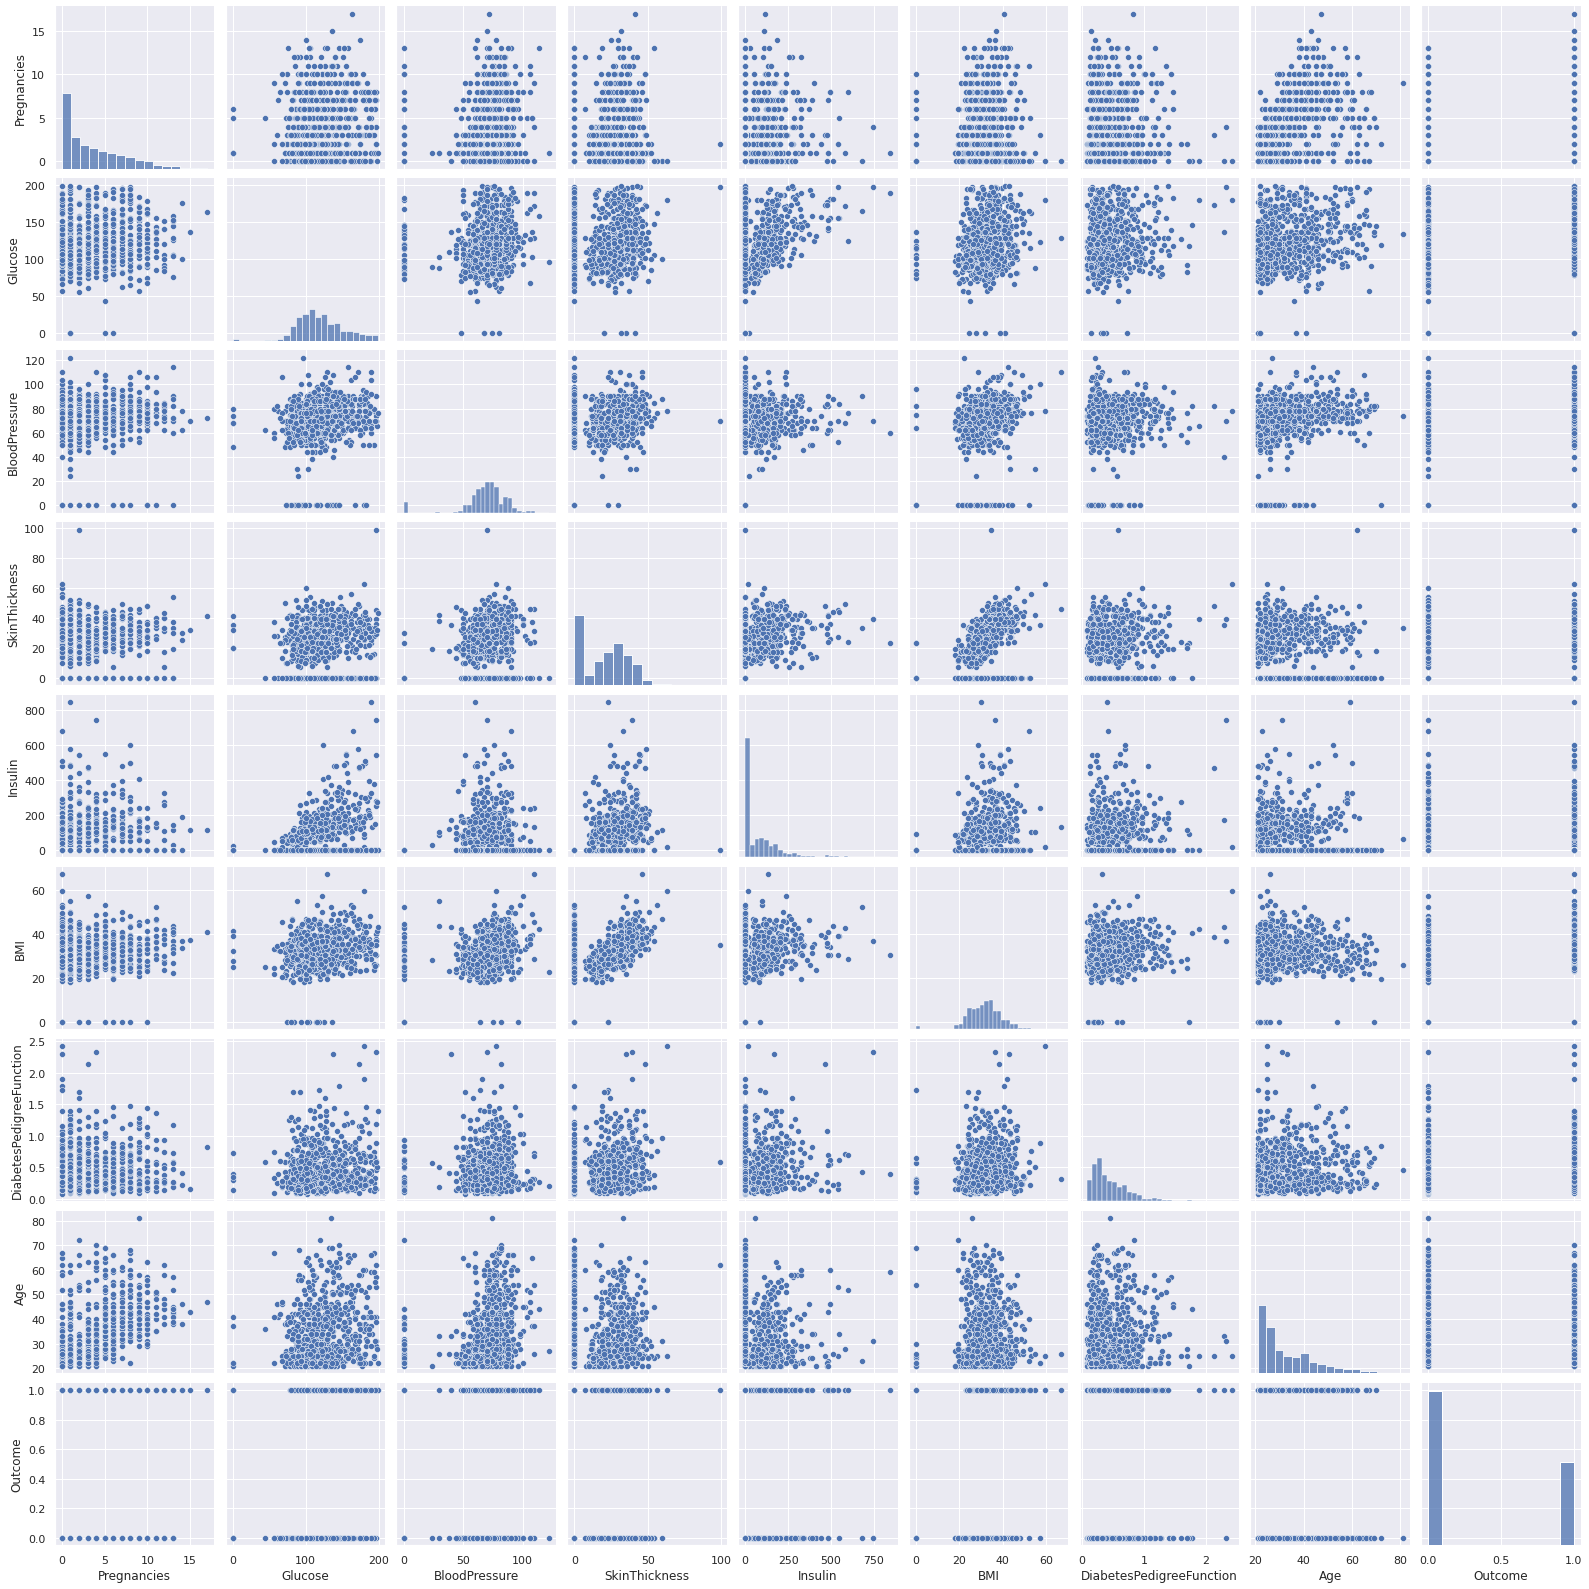

In [15]:
sns.pairplot(data,vars=num_var)
plt.show()

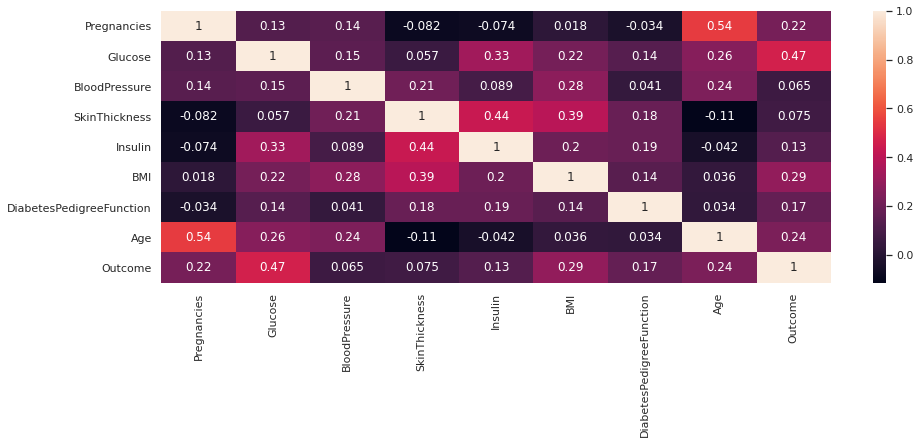

In [16]:
cor=data.corr()
plt.figure(figsize=(15,5))
sns.heatmap(cor, annot = True)
plt.show()

age and pregnancies variable are highly correlated. 

Also, Insulin, Skinthickess and BMI and Skinthickness are correlated. 


##### if like the notebook, Please upvote it 